In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-disease/HeartDiseaseTrain-Test.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Conv1D, Flatten, MaxPooling1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df=pd.read_csv('/kaggle/input/heart-disease/HeartDiseaseTrain-Test.csv')
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025 non-null   o

In [5]:
df.describe()

,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,target
count,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000
mean,54.434146,131.611707,246.00000,149.114146,1.071512,0.513171
std,9.072290,17.516718,51.59251,23.005724,1.175053,0.500070
min,29.000000,94.000000,126.00000,71.000000,0.000000,0.000000
25%,48.000000,120.000000,211.00000,132.000000,0.000000,0.000000
50%,56.000000,130.000000,240.00000,152.000000,0.800000,1.000000
75%,61.000000,140.000000,275.00000,166.000000,1.800000,1.000000
max,77.000000,200.000000,564.00000,202.000000,6.200000,1.000000


In [6]:
df.isnull().sum()

age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64

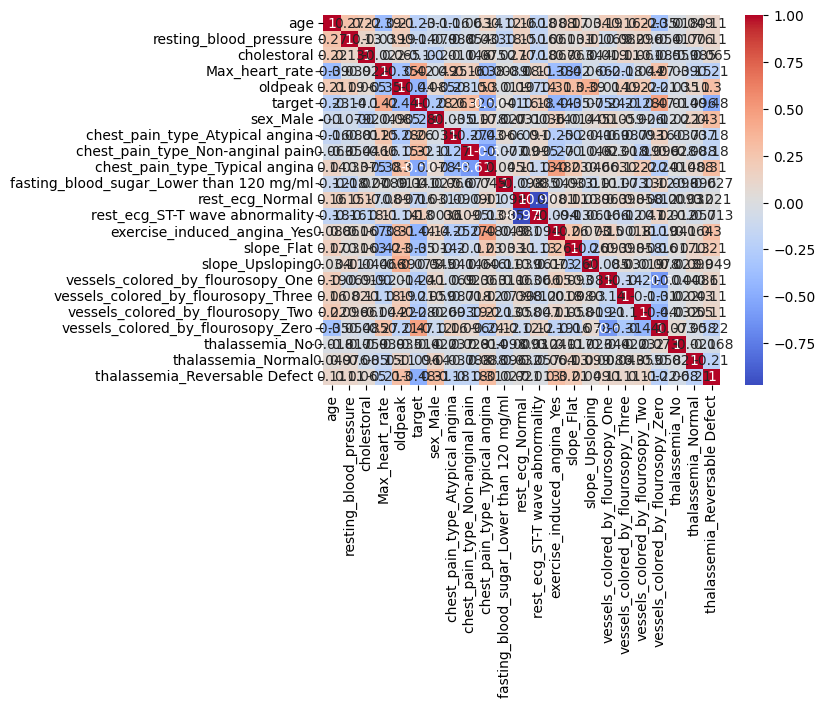

In [7]:
df = pd.get_dummies(df, drop_first=True)  # One-hot encoding

# Now compute correlation
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [8]:
# Dropping least important features
features_to_drop = ['Fbs', 'Restecg', 'Sex']
df.drop(columns=[col for col in features_to_drop if col in df.columns], inplace=True)

In [9]:
# Splitting Data
X = df.drop(columns=['target'])  # Features
y = df['target']  # Target Variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# Model 1: Optimized XGBoost (Tuned Hyperparameters)
xgb = XGBClassifier(n_estimators=300, learning_rate=0.01, max_depth=6, colsample_bytree=0.8, subsample=0.8)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9804878048780488
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       100
           1       0.98      0.98      0.98       105

    accuracy                           0.98       205
   macro avg       0.98      0.98      0.98       205
weighted avg       0.98      0.98      0.98       205



In [12]:
# Feature importance from XGBoost
important_features = pd.DataFrame({'Feature': X.columns, 'Importance': xgb.feature_importances_})
important_features = important_features.sort_values(by='Importance', ascending=False)
print("Important Features from XGBoost:")
print(important_features)

Important Features from XGBoost:
                                     Feature  Importance
8             chest_pain_type_Typical angina    0.284496
21             thalassemia_Reversable Defect    0.111853
18        vessels_colored_by_flourosopy_Zero    0.102003
12               exercise_induced_angina_Yes    0.060470
13                                slope_Flat    0.045055
5                                   sex_Male    0.041711
4                                    oldpeak    0.037157
7           chest_pain_type_Non-anginal pain    0.029673
0                                        age    0.028318
17         vessels_colored_by_flourosopy_Two    0.027541
16       vessels_colored_by_flourosopy_Three    0.025420
3                             Max_heart_rate    0.023395
14                           slope_Upsloping    0.022772
15         vessels_colored_by_flourosopy_One    0.022734
2                                cholestoral    0.022577
10                           rest_ecg_Normal    0.02231

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2

# Selecting top 10 important features using XGBoost
selected_features = important_features['Feature'][:10].tolist()
X_train_selected = X_train.iloc[:, :10] if isinstance(X_train, pd.DataFrame) else X_train[:, :10]
X_test_selected = X_test.iloc[:, :10] if isinstance(X_test, pd.DataFrame) else X_test[:, :10]

# Model 2: Hybrid Deep Neural Network
nn_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_selected.shape[1],), kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.2),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

In [15]:
# Train Neural Network
nn_model.fit(X_train_selected, y_train, epochs=100, batch_size=16, validation_data=(X_test_selected, y_test),
             verbose=1, callbacks=[early_stopping, lr_scheduler])

Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7187 - loss: 0.8415 - val_accuracy: 0.7951 - val_loss: 0.6522 - learning_rate: 0.0010
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8269 - loss: 0.6188 - val_accuracy: 0.8049 - val_loss: 0.6116 - learning_rate: 0.0010
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8291 - loss: 0.5910 - val_accuracy: 0.8146 - val_loss: 0.5628 - learning_rate: 0.0010
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8276 - loss: 0.5572 - val_accuracy: 0.8195 - val_loss: 0.5646 - learning_rate: 0.0010
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8408 - loss: 0.5396 - val_accuracy: 0.8390 - val_loss: 0.5194 - learning_rate: 0.0010
Epoch 6/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8638 - loss: 0.4889 - val_accuracy: 0.8488 - val_loss: 0.4965 - learning_rate: 0.0010
Epoch 7/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8468 - loss: 0.4757 - val_acc

In [16]:
# Model 3: CNN-LSTM Hybrid (For Time-Series Heart Data - Optional Extension)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

cnn_lstm = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    LSTM(64, return_sequences=True),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

cnn_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

cnn_lstm.fit(X_train_cnn, y_train, epochs=50, batch_size=16, validation_data=(X_test_cnn, y_test),
              verbose=1, callbacks=[early_stopping, lr_scheduler])

cnn_pred = (cnn_lstm.predict(X_test_cnn) > 0.5).astype('int')
print("CNN-LSTM Accuracy:", accuracy_score(y_test, cnn_pred))
print(classification_report(y_test, cnn_pred))


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6747 - loss: 0.6029 - val_accuracy: 0.7902 - val_loss: 0.4504 - learning_rate: 0.0010
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7979 - loss: 0.4371 - val_accuracy: 0.8000 - val_loss: 0.4169 - learning_rate: 0.0010
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8257 - loss: 0.3484 - val_accuracy: 0.8146 - val_loss: 0.4035 - learning_rate: 0.0010
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8362 - loss: 0.3621 - val_accuracy: 0.8195 - val_loss: 0.3638 - learning_rate: 0.0010
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8263 - loss: 0.3671 - val_accuracy: 0.8244 - val_loss: 0.3431 - learning_rate: 0.0010
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
CNN-LSTM Accuracy: 0.7902439024390244
              precision    recall  f1-score   support

           0       0.78      0.80      0.79       100
           1       0.80      0.78      0.79       105

    accuracy        

In [17]:
import numpy as np
from sklearn.metrics import accuracy_score

# Ensure the test data is in NumPy float32 format
X_test_selected = np.asarray(X_test_selected, dtype=np.float32) if isinstance(X_test_selected, pd.DataFrame) else X_test_selected
X_test = np.asarray(X_test, dtype=np.float32) if isinstance(X_test, pd.DataFrame) else X_test

# Ensure correct shape for MLP (Neural Network)
if len(X_test_selected.shape) == 1:
    X_test_selected = X_test_selected.reshape(1, -1)

# Ensure correct shape for CNN-LSTM (samples, time_steps, features)
X_test_lstm = X_test.reshape((X_test.shape[0], 22, 1))  # Fixing shape issue

# Print for debugging
print("✅ Expected NN Input Shape:", nn_model.input_shape)
print("✅ Actual X_test_selected Shape:", X_test_selected.shape)
print("✅ Expected LSTM Input Shape:", cnn_lstm.input_shape)
print("✅ Actual X_test_lstm Shape:", X_test_lstm.shape)

# Best Model Selection
models = [('XGBoost', xgb), ('Neural Network', nn_model), ('CNN-LSTM', cnn_lstm)]

def get_accuracy(model_name, model):
    """ Helper function to compute accuracy based on model type """
    try:
        if isinstance(model, Sequential) and 'LSTM' in [layer.__class__.__name__ for layer in model.layers]:
            # CNN-LSTM model
            print(f"🔹 Running CNN-LSTM model on input shape: {X_test_lstm.shape}")
            y_pred = model.predict(X_test_lstm)
        elif isinstance(model, Sequential):
            # Standard Neural Network (MLP)
            print(f"🔹 Running MLP model on input shape: {X_test_selected.shape}")
            y_pred = model.predict(X_test_selected)
        else:
            # XGBoost
            print(f"🔹 Running XGBoost model on input shape: {X_test.shape}")
            y_pred = model.predict(X_test)

        # Ensure y_pred is thresholded for classification
        if len(y_pred.shape) > 1:
            y_pred = (y_pred > 0.5).astype(int)
        else:
            y_pred = (y_pred > 0.5).astype(int).flatten()

        return accuracy_score(y_test, y_pred)

    except Exception as e:
        print(f"❌ Error in model {model_name}: {e}")
        return 0  # Return 0 accuracy if there's an issue

# Find the best model
best_model = max(models, key=lambda x: get_accuracy(x[0], x[1]))
print(f"🏆 Best Model: {best_model[0]}")


✅ Expected NN Input Shape: (None, 10)
✅ Actual X_test_selected Shape: (205, 10)
✅ Expected LSTM Input Shape: (None, 22, 1)
✅ Actual X_test_lstm Shape: (205, 22, 1)
🔹 Running XGBoost model on input shape: (205, 22)
🔹 Running MLP model on input shape: (205, 10)
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
🔹 Running CNN-LSTM model on input shape: (205, 22, 1)
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
🏆 Best Model: XGBoost
